In [11]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import cmasher as cmr

from sklearn.linear_model import LinearRegression
from scipy.signal import savgol_filter
from sm import NeuralNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 8,    # affects horizontal colorbar ticks
    "ytick.labelsize": 8,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 8,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

cuda


In [4]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_uni_n_a=200.pth', weights_only=False, map_location='cpu')
args = state_dict['args']

model = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'], batch_norm=False)
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

0.006012024048096192


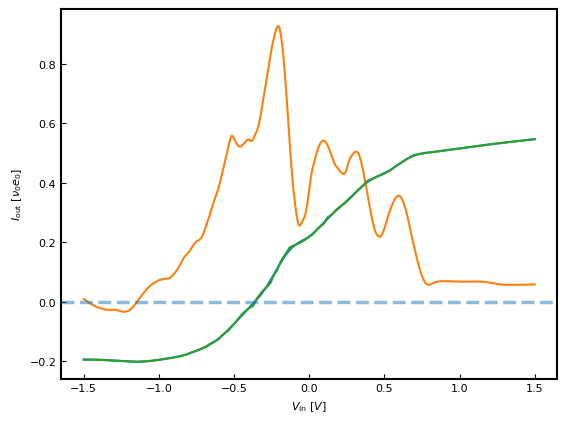

In [5]:
input_idx = 0
min_v = -1.5
max_v = 1.5
N = 500

v_step = float((max_v - min_v) / (N - 1))
print(v_step)

c_volts = torch.from_numpy(np.random.uniform(min_v, max_v, 6)).expand(N, -1).type(torch.float32)
c_v_left, c_v_right = c_volts[:, :input_idx], c_volts[:, input_idx:]

input_range = torch.linspace(min_v, max_v, N).unsqueeze(1)
input_tensor = torch.cat([c_v_left, input_range, c_v_right], dim=1)
input_tensor = input_tensor.to(device)

model.eval()
with torch.no_grad():
    I_out = model(input_tensor).detach().cpu().numpy().squeeze()

wl = 51
po = 3
I_smooth = savgol_filter(x=I_out, window_length=wl, polyorder=po, delta=v_step, mode='interp')
I_deriv = savgol_filter(x=I_out, window_length=wl, polyorder=po, deriv=1, delta=v_step, mode='interp')

plotting_range = torch.linspace(min_v, max_v, N)

fig, ax = plt.subplots()
ax.plot(plotting_range, I_smooth)
ax.plot(plotting_range, I_deriv)
ax.plot(plotting_range, I_out)
ax.set_xlabel(r'$V_{\mathrm{in}}$ $[V]$')
ax.set_ylabel(r'$I_{\mathrm{out}}$ $[\nu_0 e_0]$')

ax.axhline(y=0.0, lw=2.5, ls='--', alpha=0.5)
ax.spines[:].set_linewidth(1.5)
ax.tick_params(direction='in')

tensor([-0.2489,  0.6610, -1.4997, -0.5930, -1.0597])


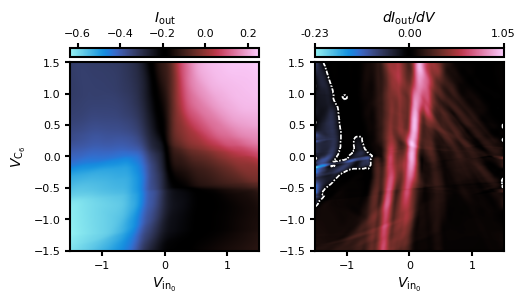

In [49]:
c_sweep_index = 6
input_idx = 0

in_features = 7

N = 500
input_range = torch.linspace(min_v, max_v, N)
c_sweep_range = torch.linspace(min_v, max_v, N)
dx = float((max_v - min_v) / (N - 1))

np.random.seed(1)
other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
print(other_controls)
window_length = 51
poly_order = 3

I_lines = []
raw_output = []
model.eval()
other_control_cols = []
for k in range(in_features):
    if k not in (c_sweep_index, input_idx):
        other_control_cols.append(k)        

for c_v in c_sweep_range:
    input_tensor = torch.empty(N, 7, dtype=torch.float32)
    input_tensor[:, c_sweep_index] = c_v
    for l, other_c_v in zip(other_control_cols, other_controls):
        input_tensor[:, l] = other_c_v
    input_tensor[:, input_idx] = input_range
    input_tensor = input_tensor.to(device)
    with torch.no_grad():
        y_out = model(input_tensor).detach().cpu().squeeze().numpy()
    I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
    I_lines.append(I_smooth)
    raw_output.append(y_out)
    
c_i_mat = np.stack(I_lines)

grad_list = []
for line in raw_output:
    #dIdV = np.gradient(line, dx)
    dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
    grad_list.append(dIdV)
grad = np.stack(grad_list)    

cmap = cmr.rainforest
cmap = plt.get_cmap('cmr.redshift')
norm = mcolors.TwoSlopeNorm(vmin=grad.min(), vcenter=0.0, vmax=grad.max())

latex_lw = 404.02908
in_inch = latex_lw / 72.27

scale=1.0
fig, ax = plt.subplots(ncols=2, figsize=(scale*in_inch, scale*in_inch))
fig.subplots_adjust(wspace=0.3)

ax[0].spines[:].set_linewidth(1.5)
ax[1].spines[:].set_linewidth(1.5)

ax[0].tick_params(width=1.5)
ax[1].tick_params(width=1.5)

extent = [input_range[0], input_range[-1], c_sweep_range[0], c_sweep_range[-1]]
im_0 = ax[0].imshow(c_i_mat, origin='lower', extent=extent, cmap=cmap)
im_1 = ax[1].imshow(grad, origin='lower', extent=extent, cmap=cmap, norm=norm)

divider_0 = make_axes_locatable(ax[0])
cax_0 = divider_0.append_axes('top', size='5%', pad=0.05)
cb_0 = fig.colorbar(im_0, cax=cax_0, orientation='horizontal')
cb_0.ax.xaxis.set_ticks_position('top')
cb_0.ax.xaxis.set_label_position('top')
cb_0.outline.set_linewidth(1.5)
cb_0.ax.xaxis.set_tick_params(width=1.5)
cb_0.set_label(label=r'$I_{\mathrm{out}}$')

divider_1 = make_axes_locatable(ax[1])
cax_1 = divider_1.append_axes('top', size='5%', pad=0.05)
#ticks = np.linspace(grad.min(), grad.max(), 3)
ticks = [grad.min(), 0.0, grad.max()]
cb_1 = fig.colorbar(im_1, cax=cax_1, orientation='horizontal')
cb_1.ax.xaxis.set_ticks_position('top')
cb_1.ax.xaxis.set_label_position('top')
cb_1.outline.set_linewidth(1.5)
cb_1.ax.xaxis.set_tick_params(width=1.5)
cb_1.set_label(label=r'$dI_{\mathrm{out}} / dV$')
cb_1.set_ticks(ticks)
cb_1.ax.set_xticklabels([f'{t:.2f}' for t in ticks])

eps = 1e-9
neg_mask = grad < -1e-2
#print(neg_mask.mean())
cs = ax[1].contour(neg_mask.astype(float), levels=[0], colors='w', linewidths=1.2, linestyles=[(0, (3, 1, 1, 1))], extent=extent)

ax[0].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}}$')
ax[0].set_ylabel(fr'$V_{{\mathrm{{C_{{{c_sweep_index}}}}}}}$')

ax[1].set_xlabel(fr'$V_{{\mathrm{{in_{{{input_idx}}}}}}}$')

for a in ax:
    pass

plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/ndr_regions_c={c_sweep_index}.pdf')
plt.show()

In [7]:
def ndr_regions(model, c_sweep_idx, in_sweep_idx, other_controls, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    model.eval()
    
    in_features = model.layer_dims[0]
    dx = float((max_v - min_v) / (resolution - 1))
    
    I_lines = []
    raw_output = []
    other_control_cols = []

    c_sweep_range = torch.linspace(min_v, max_v, resolution)
    in_sweep_range = torch.linspace(min_v, max_v, resolution)
    
    for k in range(in_features):
        if k not in (c_sweep_idx, in_sweep_idx):
            other_control_cols.append(k)

    for c_v in c_sweep_range:
        input_tensor = torch.empty(resolution, in_features, dtype=torch.float32)
        input_tensor[:, c_sweep_idx] = c_v
        for l, other_c_v in zip(other_control_cols, other_controls):
            input_tensor[:, l] = other_c_v
        input_tensor[:, in_sweep_idx] = in_sweep_range
        input_tensor = input_tensor.to(device)
        with torch.no_grad():
            y_out = model(input_tensor).detach().cpu().squeeze().numpy()
        I_smooth = savgol_filter(x=y_out, window_length=window_length, polyorder=poly_order, delta=dx, mode='interp')
        I_lines.append(I_smooth)
        raw_output.append(y_out)
        
    I_ij = np.stack(I_lines)

    grad_list = []
    
    for line in raw_output:
        dIdV = savgol_filter(x=line, window_length=window_length, polyorder=poly_order, deriv=1, delta=dx, mode='interp')
        grad_list.append(dIdV)
    grad_ij = np.stack(grad_list)    

    out_dict = {'I_ij': I_ij, 'grad_ij': grad_ij}

    return out_dict

def ndr_statistics(num_samples, neg_threshold, model, c_sweep_idx, in_sweep_idx, min_v=-1.5, max_v=1.5, resolution=500, window_length=51, poly_order=3):

    ndr_area_list = []
    peak_strength_list = []
    avg_negativity_list = []
    
    for _ in range(num_samples):

        other_controls = torch.tensor(np.random.uniform(min_v, max_v, 5)).type(torch.float32)
        out = ndr_regions(model=model, c_sweep_idx=c_sweep_idx, in_sweep_idx=in_sweep_idx, other_controls=other_controls, min_v=min_v, max_v=max_v, resolution=resolution, window_length=window_length, poly_order=poly_order)
        
        neg_mask = out['grad_ij'] < -neg_threshold
        ndr_area_list.append(neg_mask.mean())

        peak_strength_list.append(out['grad_ij'].min())

        neg_vals = out['grad_ij'][out['grad_ij'] < 0.0]

        if neg_vals.size > 0:
            avg_negativity_list.append(neg_vals.mean())
        if neg_vals.size == 0:
            avg_negativity_list.append(0.0)

    ndr_area_avg = np.array(ndr_area_list).mean()
    peak_strength_avg = np.array(peak_strength_list).mean()
    avg_negativity_avg = np.array(avg_negativity_list).mean()

    ndr_stats_dict = {
        'ndr_area_samples': ndr_area_list,
        'peak_strength_samples': peak_strength_list,
        'avg_negativity_samples': avg_negativity_list
    }

    return ndr_stats_dict

In [10]:
stats = ndr_statistics(num_samples=200, neg_threshold=0.01, model=model, c_sweep_idx=1, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)

In [53]:
state_dict = torch.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/models/sm_radial_n_a=200.pth', weights_only=False, map_location='cpu')
args = state_dict['args']

model = NeuralNet(args['layer_dims'], args['x_mean'], args['x_std'], args['y_mean'], args['y_std'], batch_norm=True)
model.load_state_dict(state_dict['model_state_dict'])

model = model.to(device)

controls = [1, 2, 3, 4, 5, 6]

area_mean = []
peak_mean = []
negativity_mean = []

area_std = []
peak_std = []
negativity_std = []

for c_idx in controls:

    stats = ndr_statistics(num_samples=200, neg_threshold=0.01, model=model, c_sweep_idx=c_idx, in_sweep_idx=0, min_v=-1.5, max_v=1.5, resolution=100, window_length=51, poly_order=3)
    ndr_areas_samples = np.array(stats['ndr_area_samples'])
    peak_strength_samples = np.array(stats['peak_strength_samples'])
    avg_negativity_samples = np.array(stats['avg_negativity_samples'])
    
    area_mean.append(ndr_areas_samples.mean())
    area_std.append(ndr_areas_samples.std())
    
    peak_mean.append(peak_strength_samples.mean())
    peak_std.append(peak_strength_samples.std())
    
    negativity_mean.append(avg_negativity_samples.mean())
    negativity_std.append(avg_negativity_samples.std())
    print(c_idx)

1
2
3
4
5
6


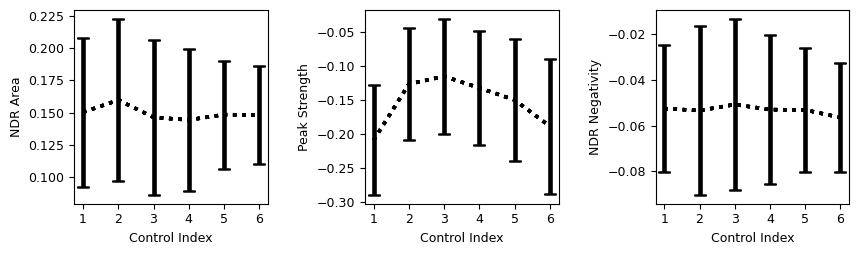

In [54]:
ncols = 3
fig, ax = plt.subplots(ncols=ncols, figsize=(10, 10))
fig.subplots_adjust(wspace=0.5)

for a in ax:
    a.set_box_aspect(1)
    a.set_xticks(np.arange(1, 7, 1))
    a.set_xlabel(r'Control Index')

for c_idx in controls:
    ax[0].errorbar(
        controls,
        area_mean,
        yerr=area_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[0].set_ylabel(f'NDR Area')

    ax[1].errorbar(
        controls,
        peak_mean,
        yerr=peak_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    ) 
    ax[1].set_ylabel(f'Peak Strength')

    ax[2].errorbar(
        controls,
        negativity_mean,
        yerr=negativity_std,
        capsize=4,
        linewidth=2.5,
        ls='dotted',
        c='k'
    )
    ax[2].set_ylabel(f'NDR Negativity')

plt.savefig(f'/home/hd/hd_hd/hd_gy283/kmc_project/plots/ndr_statistics_radial.pdf')